In [1]:
# Cell 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

In [2]:
# Cell 2: Load Training Metrics
project_root = Path().resolve().parents[0] # Adjust based on notebook location
base_dir = project_root / "experiments" / "nids_gnn"
csv_filename = "nids_training_metrics.csv"

# 1. Get all subdirectories, sorted in descending order (latest timestamp first)
if base_dir.exists():
    timestamp_folders = sorted(
        [d for d in base_dir.iterdir() if d.is_dir()], 
        reverse=True  # This correctly sorts ISO/Standard timestamps like YYYYMMDD_HHMMSS
    )
else:
    timestamp_folders = []

# 2. Find the most recent folder that actually contains the CSV
metrics_path = next(
    (folder / csv_filename for folder in timestamp_folders if (folder / csv_filename).exists()), 
    None
)

# 3. Load the data or report failure
if metrics_path:
    print(f"Loading metrics from latest run: {metrics_path.parent.name}")
    df_metrics = pd.read_csv(metrics_path)
    display(df_metrics.head())
else:
    print(f"File '{csv_filename}' not found in any subfolders under {base_dir}. Make sure to run the training first.")

Loading metrics from latest run: 20261005_161824


,Epoch,Train_Loss,Val_F1,Val_AUC
0,1,1.111868,0.625995,0.728584
1,2,1.014727,0.635097,0.753892
2,3,0.951814,0.679641,0.821194
3,4,0.898783,0.705521,0.836140
4,5,0.891032,0.713826,0.842032


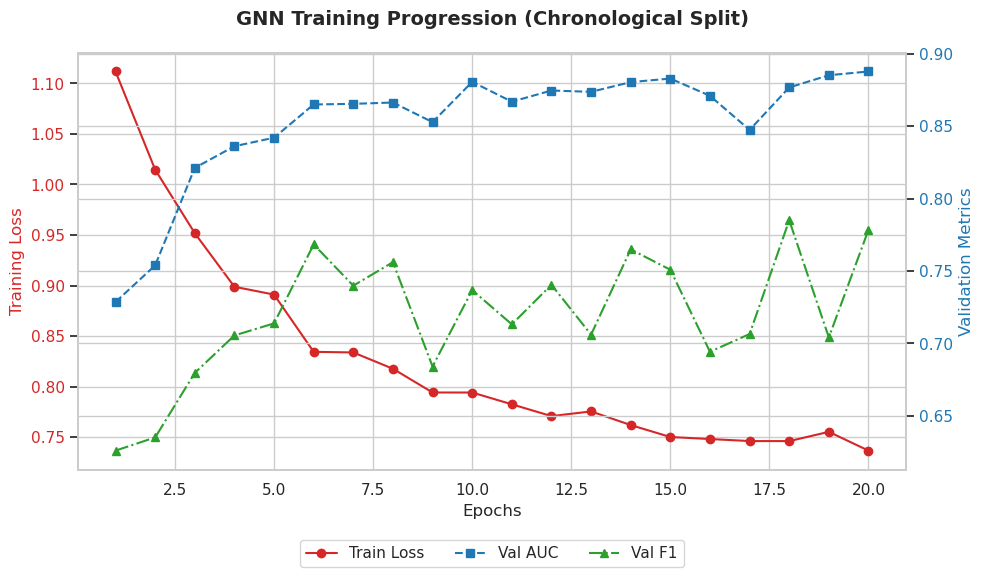

In [ ]:
# Cell 3: Plot Training Loss vs Validation AUC/F1
# Assuming metrics_path is defined and valid from the previous cell
if metrics_path: 
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Training Loss on left Y-axis
    color = 'tab:red'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Training Loss', color=color)
    ax1.plot(df_metrics['Epoch'], df_metrics['Train_Loss'], color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    # Create a second Y-axis for AUC and F1
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Validation Metrics', color=color)  
    ax2.plot(df_metrics['Epoch'], df_metrics['Val_AUC'], color=color, marker='s', linestyle='--', label='Val AUC')
    ax2.plot(df_metrics['Epoch'], df_metrics['Val_F1'], color='tab:green', marker='^', linestyle='-.', label='Val F1')
    ax2.tick_params(axis='y', labelcolor=color)

    # --- NEW LEGEND CODE ---
    # Extract lines and labels from both axes to create a single legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    
    # Combine them and place the legend (e.g., upper left, or outside the plot)
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    # Title and Layout
    plt.title("GNN Training Progression (Chronological Split)", pad=20, fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()

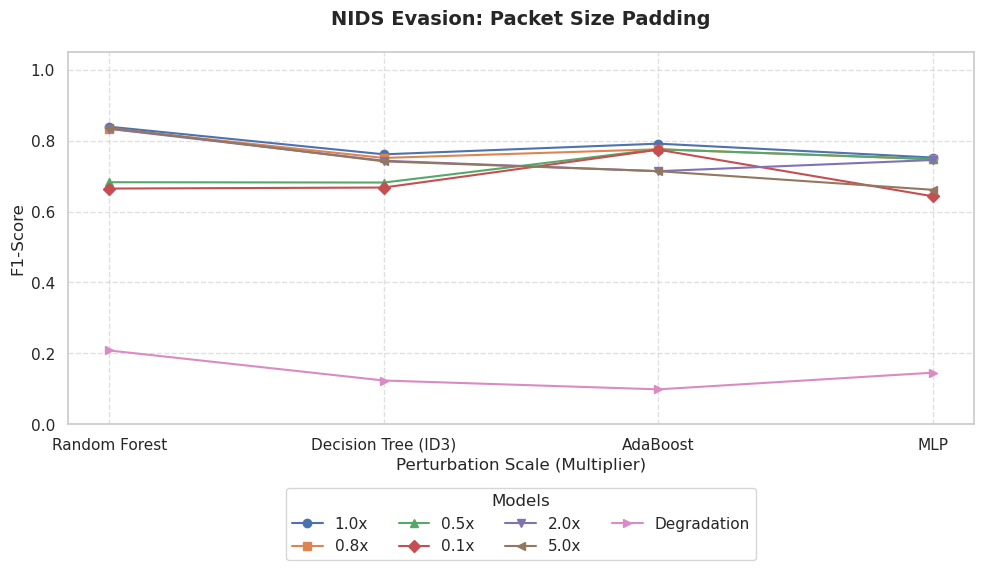

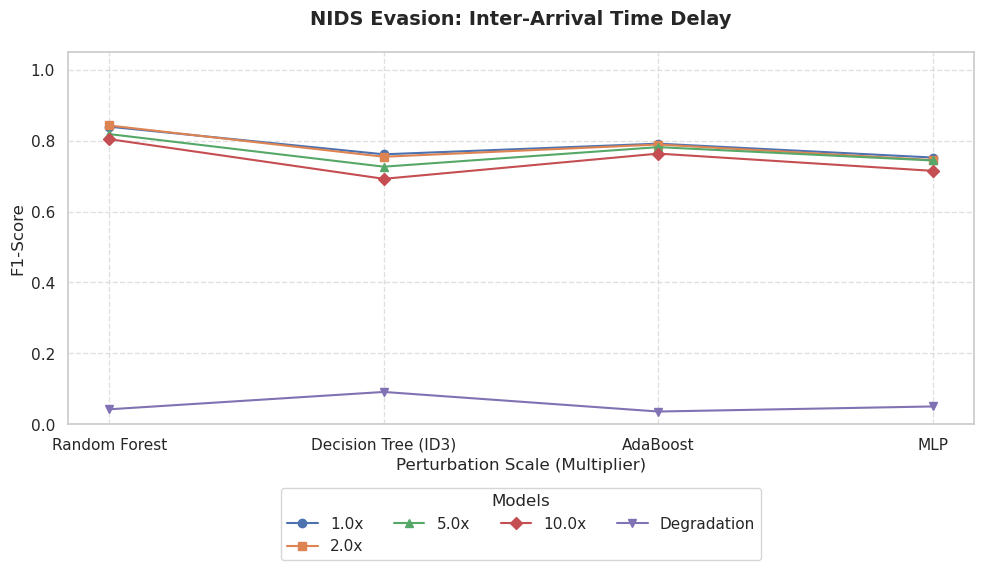

In [ ]:
project_root = Path().resolve().parents[0]
base_dir = project_root / "experiments" / "nids_gnn"
csv_filename = "nids_training_metrics.csv"

# Locate latest run folder containing the CSV
metrics_path = None
if base_dir.exists():
    timestamp_folders = sorted([d for d in base_dir.iterdir() if d.is_dir()], reverse=True)
    metrics_path = next((folder / csv_filename for folder in timestamp_folders if (folder / csv_filename).exists()), None)

if metrics_path:
    print(f"Loading metrics from latest run: {metrics_path.parent.name}")
    df_metrics = pd.read_csv(metrics_path)
    display(df_metrics)
else:
    print(f"[Error] '{csv_filename}' not found under {base_dir}. Run 'python orchestrator.py -t train_nids' first.")

In [ ]:
if metrics_path and "df_metrics" in locals():
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Left Y-Axis: Training Loss
    loss_color = "tab:red"
    ax1.set_xlabel("Epochs", fontsize=12)
    ax1.set_ylabel("Training Loss", color=loss_color, fontsize=12)
    line1 = ax1.plot(df_metrics["Epoch"], df_metrics["Train_Loss"], color=loss_color, marker="o", linewidth=2, label="Train Loss")
    ax1.tick_params(axis="y", labelcolor=loss_color)
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Right Y-Axis: Validation Metrics (AUC & F1)
    ax2 = ax1.twinx()
    auc_color = "tab:blue"
    f1_color = "tab:green"
    ax2.set_ylabel("Validation Metrics (0.0 - 1.0)", color="black", fontsize=12)
    line2 = ax2.plot(df_metrics["Epoch"], df_metrics["Val_AUC"], color=auc_color, marker="s", linestyle="--", linewidth=2, label="Val AUC")
    line3 = ax2.plot(df_metrics["Epoch"], df_metrics["Val_F1"], color=f1_color, marker="^", linestyle="-.", linewidth=2, label="Val F1")
    ax2.set_ylim(0.0, 1.05)
    ax2.tick_params(axis="y", labelcolor="black")

    # Unified Legend Below the Plot
    all_lines = line1 + line2 + line3
    labels = [line.get_label() for line in all_lines]
    ax1.legend(all_lines, labels, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fontsize=11)

    plt.title("NIDS GNN (MFGraph) Training Progression", pad=20, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()